In [64]:
import torch
import numpy as np
import scipy
import matplotlib.pyplot as plt

from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference.base import infer

import torch.nn as nn
import torch.nn.functional as F
from sbi import inference
from sbi.inference import SNPE, simulate_for_sbi, prepare_for_sbi

from typing import Tuple, Optional
from torch import Tensor
import rnn

In [65]:
from  subhalo_impact import chi_eval
from rotation_matrix import obs_from_pos6d

In [66]:
def replace_with_neighboring_value(values, values_stats, empty_bin_indices, phi1, phi1_edges):
    values_stats = np.copy(values_stats)
    for i in empty_bin_indices:
        neighboring_bin1 = i-1
        neighboring_bin2 = i+1
        
        while neighboring_bin1 in empty_bin_indices:
            neighboring_bin1 -= 1
        
        while neighboring_bin2 in empty_bin_indices:
                neighboring_bin2 += 1
        
        median, _, _ = scipy.stats.binned_statistic(phi1, values, statistic='median', bins = 1, range = (phi1_edges[neighboring_bin1], phi1_edges[neighboring_bin2+1]))
        values_stats[i] = median[0]
    return values_stats

In [67]:
def replace_with_neighboring_value_std(std_stats, empty_bin_indices):
    std_stats = np.copy(std_stats)
    for i in empty_bin_indices:
        neighboring_bin1 = i-1
        neighboring_bin2 = i+1
        
        while neighboring_bin1 in empty_bin_indices:
            neighboring_bin1 -= 1
        
        while neighboring_bin2 in empty_bin_indices:
                neighboring_bin2 += 1
        
        std_stats[i] = np.median([std_stats[neighboring_bin1], std_stats[neighboring_bin2]])
    return std_stats

In [68]:
def simulator (params, scatter = 0.1, bins = 100):
    params = np.array(params, dtype=float) # convert tensor to np ndarray
    log_Msat = params[0]
    M_sat = 10**log_Msat
    vz = params[1]
    # r = params[2]

    r = 0.2
    phi = 250 # angle around stream in dec
    vphi = 35  # velocity around stream in km/s
    t_a = 0.2 # time since interaction in Gyr
    phi_a = -4 # interaction point along stream in deg, phi=0 is progenitor location (try -20 to 10)
    rs_sat = 1.05 * (M_sat*10*10)**0.5 # scale radius of subhalo in kpc, can be adjusted along with M_sat using equation 15 in erkal et al. 2015
    # pid=36 # index included in saved filenames
    tmax=4 # how long stream disrupts in Gyr

    chi_eval(r,phi,vphi,vz,M_sat,tmax,t_a,phi_a,rs_sat,pid)
    data = np.genfromtxt(f'final_stream/final_stream (M_sat: {round(M_sat, 5)}, vz: {round(vz, 1)}).txt')
    R_phi12_radec = np.array([[0.83697865, 0.29481904, -0.4610298], 
                          [0.51616778, -0.70514011, 0.4861566], 
                          [0.18176238, 0.64487142, 0.74236331]])
    phi1,phi2,dist,pm1,pm2,vr = obs_from_pos6d(data[:,:3],data[:,3:6],R_phi12_radec)

    '''to include in the output:
        phi1 edges
        fraction = count / len(phi1)
        phi2 median
        vr median

        phi2 std
        vr std
    '''

    phi2_median, phi1_edges, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='median', bins = bins)
    phi2_std, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='std', bins = bins)
    count, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='count', bins = bins)
    vr_median, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='median', bins = bins)
    vr_std, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='std', bins = bins)

    '''fill in empty bins with neighboring values'''
    nan_indices = np.argwhere(np.isnan(phi2_median)).flatten()
    phi2_median_new = replace_with_neighboring_value(phi2, phi2_median, nan_indices, phi1, phi1_edges)
    vr_median_new = replace_with_neighboring_value(vr, vr_median, nan_indices, phi1, phi1_edges)

    phi2_std_new = replace_with_neighboring_value_std(phi2_std, nan_indices)
    vr_std_new = replace_with_neighboring_value_std(vr_std, nan_indices)

    output = np.vstack((phi1_edges[:-1], phi2_median_new, count/len(phi1), vr_median_new, phi2_std_new, vr_std_new))
    output = torch.from_numpy(output)
    
    return (output + torch.randn_like(output) * scatter).T

In [69]:
# # log M_sat, r, vz
# num_dim = 3

# # need to change to more accurate distributions (range, mean, etc.)
# prior_min = [0.00001, -50, 0]
# prior_max = [10, 0, 30]


num_dim = 2
prior_min = [-5, -50]
prior_max = [1, 0]

prior_uniform = utils.BoxUniform(low = torch.as_tensor(prior_min), high=torch.as_tensor(prior_max))

prior_normal = torch.distributions.MultivariateNormal(5 * torch.ones(num_dim), 1 * torch.eye(num_dim))


# make a SBI-wrapper on the simulator object for compatibility
simulator_wrapper, prior = prepare_for_sbi(simulator, prior_uniform)

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=[ -2.44791698 -41.39093018],tapproach=0.2,phiapproach=-4,pid=36


/Users/rutongpei/Documents/GitHub/SBI-streameeeee/sims/subhalo_orbit.py:220: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  impact_velG = np.array([vh_vx+vx_o,vh_vy+vy_o,vh_vz+vz_o])


Correct usage: ./a.out x y z vx vy vz M_LMC rs_LMC x_LMC y_LMC z_LMC vx_LMC vy_LMC vz_LMC Mprog tmax M_NFW rs_NFW c_NFW x_sat y_sat z_sat vx_sat vy_sat vz_sat pid
Impact with scale radius:  [3.33893387e+00 8.97242905e-04]
Correct usage: ./a.out x y z vx vy vz M_LMC rs_LMC x_LMC y_LMC z_LMC vx_LMC vy_LMC vz_LMC Mprog tmax M_NFW rs_NFW c_NFW x_sat y_sat z_sat vx_sat vy_sat vz_sat pid M_sat rs_sat
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-0.40114593505859375,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-66.980131, vy=37.319157, vz=-68.298794, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.2917189988846207
Impact pid: 36 with M_sat=0.000772, rs_sat=0.291719,  
Sanity check : Initializing potential


In [80]:
# test the embedding net, comment in to run
# define RNN parameters
n_in = 6  # number of input channels
n_out = 2  # number of output channels
num_layers = 2  # number of recurrent layers
hidden_features = 8  # number of hidden features

embedding_net = rnn.EmbeddingNet(n_in, n_out, hidden_features, num_layers)

# instantiate the neural density estimator
neural_posterior = utils.posterior_nn(
    model="maf", embedding_net=embedding_net, hidden_features=8)

# setup the inference procedure with the SNPE-C procedure
inference = SNPE(prior=prior, density_estimator=neural_posterior)

In [77]:
# run the inference procedure on one round and 10000 simulated data points
theta, x = simulate_for_sbi(simulator_wrapper, prior, num_simulations=100, simulation_batch_size = 8)

Running 100 simulations.:   0%|          | 0/100 [00:00<?, ?it/s]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-45.01511764526367,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-50.199118, vy=9.929254, vz=-37.337572, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.1230478499088022
Impact pid: 36 with M_sat=0.000137, rs_sat=0.123048,  
Sanity check : Initializing potential
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-25.181325912475586,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-57.659362, vy=22.105835, vz=-51.101835, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.12037811494895616
Impact pid: 36

Running 100 simulations.:   8%|▊         | 8/100 [05:37<1:04:45, 42.23s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-2.20904541015625,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-66.300111, vy=36.209231, vz=-67.044147, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.5350883182944256
Impact pid: 36 with M_sat=0.002597, rs_sat=0.535088,  
Sanity check : Initializing potential
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-25.089813232421875,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-57.693783, vy=22.162017, vz=-51.165343, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  8.837941806119572
Impact pid: 36 w

Running 100 simulations.:  16%|█▌        | 16/100 [11:02<57:43, 41.24s/it] 

...

Running 100 simulations.:  88%|████████▊ | 88/100 [1:00:55<08:17, 41.50s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-35.27862548828125,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-53.861383, vy=15.906789, vz=-44.094506, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  1.518527556763348
Impact pid: 36 with M_sat=0.020915, rs_sat=1.518528,  
Sanity check : Initializing potential
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-5.6845550537109375,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-64.992839, vy=34.075508, vz=-64.632211, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.651991915772591
Impact pid: 36 w

Running 100 simulations.:  96%|█████████▌| 96/100 [1:06:23<02:45, 41.34s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-38.73834228515625,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-52.560052, vy=13.782761, vz=-41.693531, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  29.731943282004607
Impact pid: 36 with M_sat=8.018036, rs_sat=29.731943,  
Sanity check : Initializing potential
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-23.97623634338379,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-58.112642, vy=22.845676, vz=-51.938143, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.060318320181290346
Impact pid: 

Running 100 simulations.: 104it [1:09:16, 39.97s/it]                        


In [81]:
density_estimator = inference.append_simulations(theta, x).train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 342 epochs.

In [ ]:
# posterior = infer(simulator, prior_uniform, "SNPE", num_simulations=100)

In [73]:
true_parameter1 = torch.tensor([-4.5, -45])
true_parameter2 = torch.tensor([0.8, -48])
true_parameter3 = torch.tensor([-3, -30])
true_parameter4 = torch.tensor([-2, -5])
true_parameter5 = torch.tensor([0.1, -28])
true_parameter6 = torch.tensor([-1.2, -37])
true_parameter7 = torch.tensor([-2.7, -11])

In [74]:
observation1 = simulator(true_parameter1)
observation2 = simulator(true_parameter2)
observation3 = simulator(true_parameter3)
observation4 = simulator(true_parameter4)
observation5 = simulator(true_parameter5)
observation6 = simulator(true_parameter6)
observation7 = simulator(true_parameter7)

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-45.0,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-50.204804, vy=9.938535, vz=-37.348063, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.05904583914498666
Impact pid: 36 with M_sat=0.000032, rs_sat=0.059046,  
Sanity check : Initializing potential
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-48.0,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-49.076390, vy=8.096742, vz=-35.266122, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  26.374807892831026
Impact pid: 36 with M_sat=6.309574, rs_sat

In [82]:
posterior_samples_1 = posterior.sample((100000,), x=observation1)
posterior_samples_2 = posterior.sample((100000,), x=observation2)
posterior_samples_3 = posterior.sample((100000,), x=observation3)
posterior_samples_4 = posterior.sample((100000,), x=observation4)
posterior_samples_5 = posterior.sample((100000,), x=observation5)
posterior_samples_6 = posterior.sample((100000,), x=observation6)
posterior_samples_7 = posterior.sample((100000,), x=observation7)

Drawing 100000 posterior samples: 101963it [00:00, 246668.83it/s]                           
Drawing 100000 posterior samples: 101419it [00:00, 242433.12it/s]                           
Drawing 100000 posterior samples: 102173it [00:00, 241428.97it/s]                           
Drawing 100000 posterior samples: 102235it [00:00, 291638.19it/s]                           
Drawing 100000 posterior samples: 102555it [00:00, 287695.16it/s]                           
Drawing 100000 posterior samples: 102186it [00:00, 292726.19it/s]                           
Drawing 100000 posterior samples: 102266it [00:00, 292075.04it/s]                           


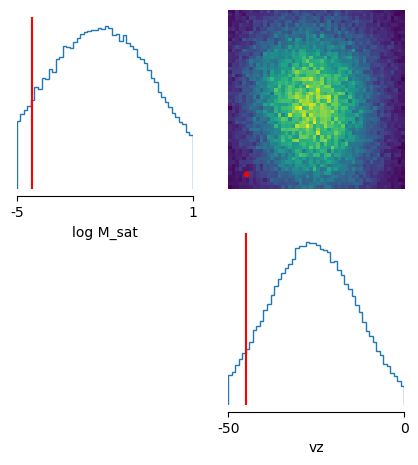

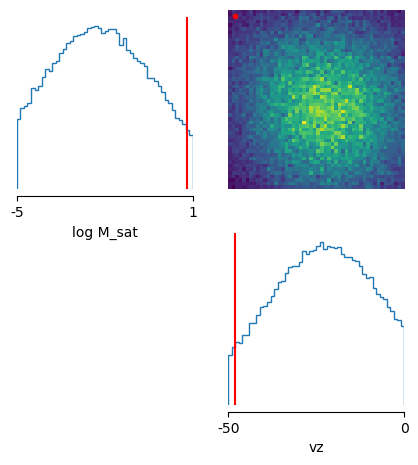

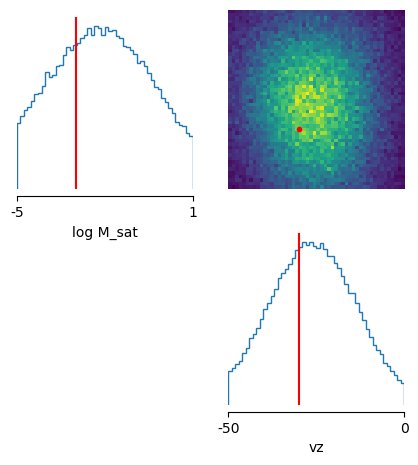

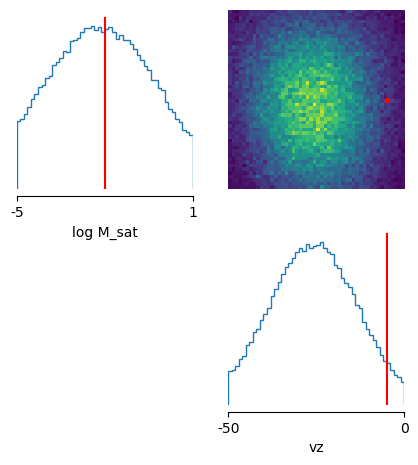

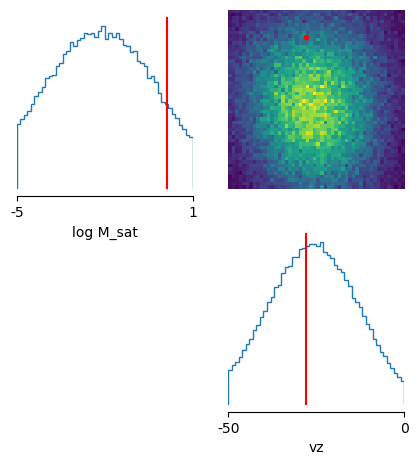

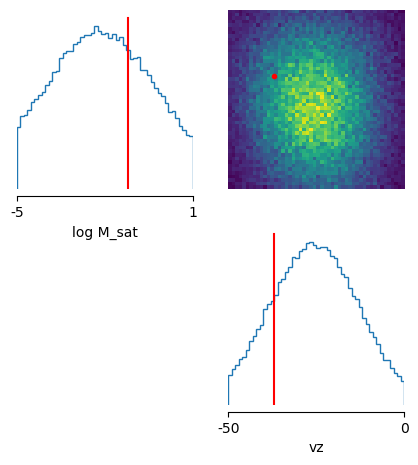

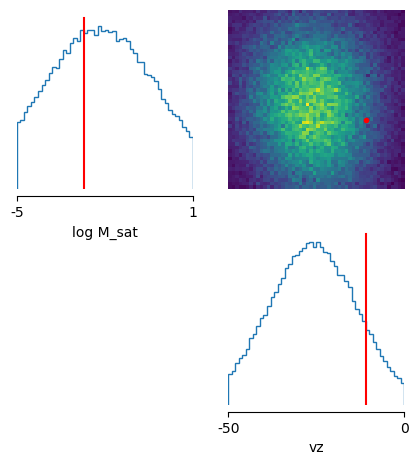

In [83]:
_ = analysis.pairplot(
    posterior_samples_1, limits = [[-5,1], [-50, 0]],
    ticks = [[-5,1], [-50, 0]],
    figsize = (5, 5),
    points = true_parameter1,
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat","vz"]
)

_ = analysis.pairplot(
    posterior_samples_2, limits = [[-5,1], [-50, 0]],
    ticks = [[-5,1], [-50, 0]],
    figsize = (5, 5),
    points = true_parameter2,
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat","vz"]
)
_ = analysis.pairplot(
    posterior_samples_3, limits = [[-5,1], [-50, 0]],
    ticks = [[-5,1], [-50, 0]],
    figsize = (5, 5),
    points = true_parameter3,
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat","vz"]
)
_ = analysis.pairplot(
    posterior_samples_4, limits = [[-5,1], [-50, 0]],
    ticks = [[-5,1], [-50, 0]],
    figsize = (5, 5),
    points = true_parameter4,
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat","vz"]
)
_ = analysis.pairplot(
    posterior_samples_5, limits = [[-5,1], [-50, 0]],
    ticks = [[-5,1], [-50, 0]],
    figsize = (5, 5),
    points = true_parameter5,
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat","vz"]
)
_ = analysis.pairplot(
    posterior_samples_6, limits = [[-5,1], [-50, 0]],
    ticks = [[-5,1], [-50, 0]],
    figsize = (5, 5),
    points = true_parameter6,
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat","vz"]
)
_ = analysis.pairplot(
    posterior_samples_7, limits = [[-5,1], [-50, 0]],
    ticks = [[-5,1], [-50, 0]],
    figsize = (5, 5),
    points = true_parameter7,
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat","vz"]
)

In [120]:
def hpd(trace, mass_frac):
    ''' 
    Returns highest probability density region given by a set of samples.

    Parameters
    ----------
    trace: array
        1D array of MCMC samples for a single variable
    mass_frac: float with 0 < mass_frac <= 1
        The fraction of the probability to be included in the HPD. For example, 'massfrac'=0.95 gives a 95% HPD.

    Returns
    -------
    output: array, shape(2,)
        The bounds of the HPD
    '''

    # Get sorted list
    d = np.sort(np.copy(trace))

    # Number of total samples taken
    n = len(trace)

    # Get number of samples that should be included in HPD
    n_samples = np.floor(mass_frac * n).astype(int)

    # Get width (in units of data) of all intervals with n_samples samples
    int_width = d[n_samples:] - d[:n-n_samples]

    # Pick out minimal interval
    min_int = np.argmin(int_width)

    # Return interval
    return np.array([d[min_int], d[min_int+n_samples]])

In [121]:
# simple version

def draw_coverage_plot_1d(simulator, posterior, true_values):
    fractions = np.array([])
    x = np.arange(0, 1, 0.1)

    samples = [[0] for _ in range(len(true_values))]
    for i in range(len(true_values)):
        simulated_samples = posterior.sample((1000,), x = simulator(torch.as_tensor([true_values[i]])))[:,0]
        samples[i] = np.array(simulated_samples)
    
    for confidence in x:
        contain_true = 0
        for i in range(len(true_values)):
            lower, upper = hpd(samples[i],confidence)
            if lower <= true_values[i] <= upper:
                contain_true += 1
        fractions = np.append(fractions, [contain_true/len(true_values)])

    plt.plot(x, fractions, label = 'model coverage')
    plt.plot([0,1],[0,1],color='r', label = 'perfect coverage')
    plt.ylim(0,1)
    plt.title("coverage for M_sat")
    plt.xlabel("confidence interval")
    plt.ylabel("covereage percentage")
    plt.show()

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.03320391543176798
Impact pid: 36 with M_sat=0.000010, rs_sat=0.033204,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1104it [00:00, 31402.03it/s]            

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential


tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.10500000000000001
Impact pid: 36 with M_sat=0.000100, rs_sat=0.105000,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1132it [00:00, 35315.46it/s]            

...

tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  3.3203915431767985
Impact pid: 36 with M_sat=0.100000, rs_sat=3.320392,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1134it [00:00, 35673.98it/s]            

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential


tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  10.5
Impact pid: 36 with M_sat=1.000000, rs_sat=10.500000,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1132it [00:00, 35942.38it/s]            


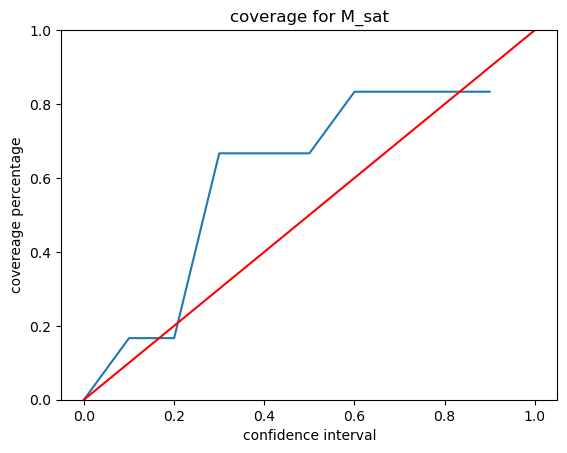

In [122]:
true_values = np.arange(-5, 1, 1)
draw_coverage_plot_1d(simulator, posterior, true_values)

In [78]:
bins = 100
pid = 36
data = np.genfromtxt(f'final_stream/final_stream_{pid}.txt')
R_phi12_radec = np.array([[0.83697865, 0.29481904, -0.4610298], 
                          [0.51616778, -0.70514011, 0.4861566], 
                          [0.18176238, 0.64487142, 0.74236331]])
phi1,phi2,dist,pm1,pm2,vr = obs_from_pos6d(data[:,:3],data[:,3:6],R_phi12_radec)

phi2_median, phi1_edges, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='median', bins = bins)
phi2_std, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='std', bins = bins)
count, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='count', bins = bins)
vr_median, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='median', bins = bins)
vr_std, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='std', bins = bins)
# (phi1_edges, phi2_median, phi2_std, count/len(phi1), vr_median, vr_std)

# print(np.sum(np.isnan(phi1_edges)))
# print(np.sum(np.isnan(phi2_median)))
# print(np.sum(np.isnan(phi2_std)))
# print(phi1_edges)
# print(phi1_edges[:-1][count==0])
# print(min(phi1), max(phi1))
# print(np.sum(np.isnan(vr_median)))
# print(np.sum(np.isnan(vr_std)))

# print(np.sum(np.isnan(vr)))
# print(np.sum(np.isnan(phi2)))